In [1]:
%%capture install_log
!pip install -q ultralytics pydicom opencv-python-headless tqdm pandas openpyxl scikit-learn pyyaml

In [2]:
!pip install monai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.1 MB/s eta 0:00:0000:0100:01


In [3]:
import os
import glob
import pandas as pd
import numpy as np
import pydicom
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import monai
from monai.transforms import (
    Compose, 
    EnsureChannelFirstd, 
    ScaleIntensityRanged, 
    Resized, 
    ToTensord,
    RandRotate90d,
    RandFlipd,
    RandGaussianNoised,
    RandZoomd
)
from sklearn.model_selection import GroupKFold
from tqdm import tqdm


2026-05-16 21:50:13.224111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778968213.442966      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778968213.508735      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778968213.997671      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778968213.997726      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778968213.997730      57 computation_placer.cc:177] computation placer alr

In [4]:

# Cihaz Kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Aktif Cihaz: {device}")

# Kaggle Dizin Yolları
DATA_DIR = "/kaggle/input/competitions/rsna-2023-abdominal-trauma-detection"
TRAIN_IMAGES_DIR = os.path.join(DATA_DIR, "train_images")
TRAIN_CSV = os.path.join(DATA_DIR, "train_2024.csv")

Aktif Cihaz: cpu


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [6]:
df_train = pd.read_csv(TRAIN_CSV)

print(f"Toplam Hasta Sayısı (Train): {df_train['patient_id'].nunique()}")
print(f"Sütun Sayısı: {len(df_train.columns)}")
df_train.head()

Toplam Hasta Sayısı (Train): 3147
Sütun Sayısı: 15


,patient_id,bowel_healthy,bowel_injury,extravasation_healthy,extravasation_injury,kidney_healthy,kidney_low,kidney_high,liver_healthy,liver_low,liver_high,spleen_healthy,spleen_low,spleen_high,any_injury
0,10004,1,0,0,1,0,1,0,1,0,0,0,0,1,1
1,10005,1,0,1,0,1,0,0,1,0,0,1,0,0,0
2,10007,1,0,1,0,1,0,0,1,0,0,1,0,0,0
3,10026,1,0,1,0,1,0,0,1,0,0,1,0,0,0
4,10051,1,0,1,0,1,0,0,1,0,0,0,1,0,1


**1. Sınıf Dengesizliği (Class Imbalance)**# 

/tmp/ipykernel_57/805436683.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_counts.values, y=injury_counts.index, palette="Reds_r")


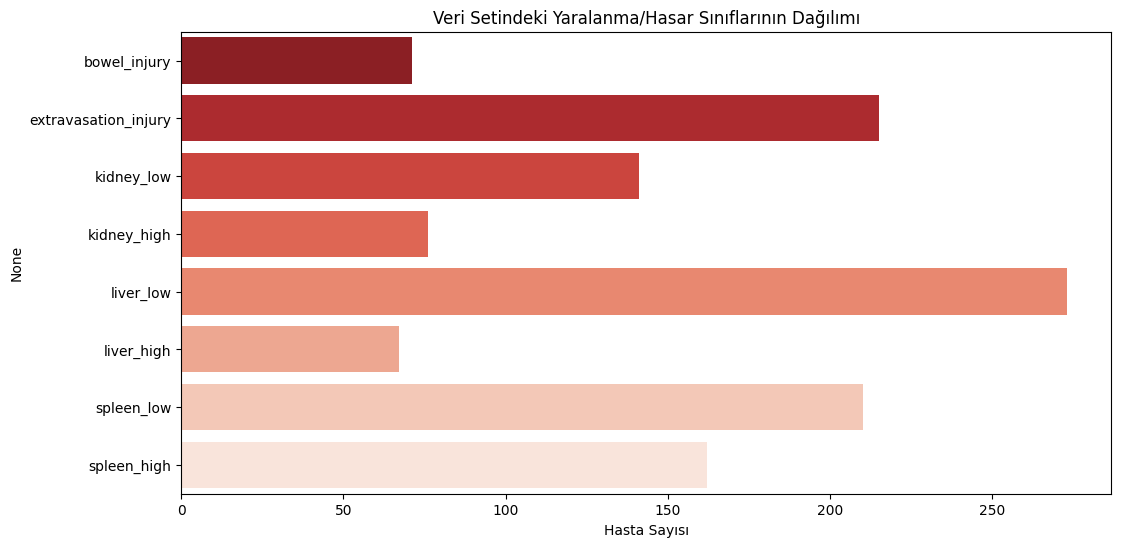

In [7]:
# Organ bazlı hasar (injury) oranlarını hesaplayalım
injury_cols = ['bowel_injury', 'extravasation_injury', 'kidney_low', 'kidney_high', 
               'liver_low', 'liver_high', 'spleen_low', 'spleen_high']

injury_counts = df_train[injury_cols].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=injury_counts.values, y=injury_counts.index, palette="Reds_r")
plt.title("Veri Setindeki Yaralanma/Hasar Sınıflarının Dağılımı")
plt.xlabel("Hasta Sayısı")
plt.show()

Keşif: Grafiği çizdiğinizde göreceksiniz ki kidney_high veya bowel_injury vakaları toplam veri setinde oldukça az yer kaplar. Modelin bu sınıfları "görmezden gelmesini" engellemek için daha önce bahsettiğimiz ağırlıklı loss (pos_weight) parametresi hayati önem taşıyacaktır.

Ağırlıklı Önem Oranı: Yarışmanın resmi metriğinde bowel_injury ve extravasation_injury yanlış tahmin edilirse skorunuzu çok kötü etkiler (ceza puanı yüksektir). Analizde bu sınıfların az olduğunu gördüğümüz için, loss fonksiyonuna kesinlikle pozitif ağırlık eklemeliyiz.

2. Çoklu Organ Yaralanmaları (Multi-Label Korelasyonu)

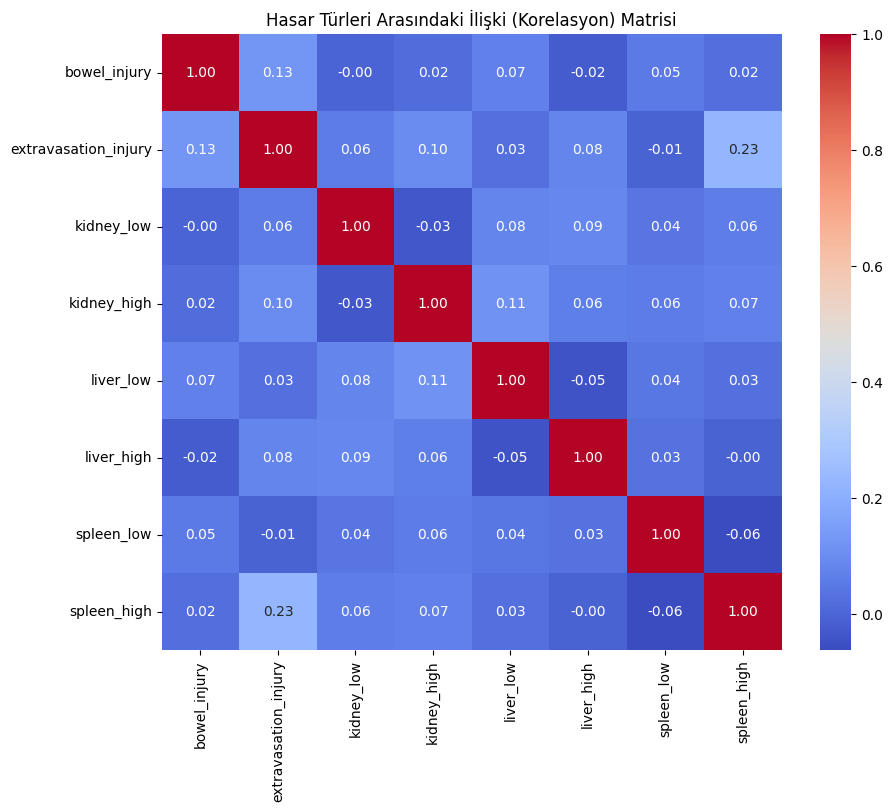

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_train[injury_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Hasar Türleri Arasındaki İlişki (Korelasyon) Matrisi")
plt.show()

Keşif: Eğer iki hasar türü arasında pozitif bir korelasyon varsa, modelimiz bu organların özelliklerini ortak katmanlarda öğrenirken birbirini destekleyecek şekilde eğtilebilir.

3. Görüntü (Slice) Sayılarındaki Tutarsızlık

In [9]:
df_meta = pd.read_csv(os.path.join(DATA_DIR, "train_series_meta.csv"))

# Her serinin kaçar görüntü içerdiğini anlamak için (Örnek olarak ilk birkaç seriyi analiz edebiliriz)
print(df_meta.head())

# Hastaların tarama sayıları (Her hastanın birden fazla serisi var mı?)
series_per_patient = df_meta.groupby('patient_id')['series_id'].count()
print(f"\nHasta başına düşen ortalama tarama (seri) sayısı: {series_per_patient.mean():.2f}")

   patient_id  series_id  aortic_hu  incomplete_organ
0       10004      21057     146.00                 0
1       10004      51033     454.75                 0
2       10005      18667     187.00                 0
3       10007      47578     329.00                 0
4       10026      29700     327.00                 0

Hasta başına düşen ortalama tarama (seri) sayısı: 1.50


In [7]:
# --- FAZ 1 & FAZ 2: ÖN İŞLEME VE VERİ ARTIRIMI (AUGMENTATION) ---

# Train Transform: Ön işleme + Faz 2 Regülasyonları
train_transforms = Compose([
    EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
    # Faz 1: HU Clipping [-150, 250] ve [0, 1] normalizasyonu
    ScaleIntensityRanged(keys=["image"], a_min=-150, a_max=250, b_min=0.0, b_max=1.0, clip=True),
    # Faz 1: 128x128x128 Hacimsel Yeniden Boyutlandırma
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    
    # Faz 2: Farklı tarama oryantasyonları ve gürültüler için Augmentation adımları
    RandRotate90d(keys=["image"], prob=0.5, spatial_axes=(0, 1)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandZoomd(keys=["image"], prob=0.3, min_zoom=0.9, max_zoom=1.1, mode="trilinear"),
    RandGaussianNoised(keys=["image"], prob=0.2, mean=0.0, std=0.05),
    
    ToTensord(keys=["image"])
])

# Validation Transform: Sadece Ön İşleme (Augmentation uygulanmaz)
val_transforms = Compose([
    EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
    ScaleIntensityRanged(keys=["image"], a_min=-150, a_max=250, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(128, 128, 128)),
    ToTensord(keys=["image"])
])

Dinamik Derinlik: Slice sayılarındaki aşırı dalgalanma yüzünden Faz 1'de uyguladığımız Resized(spatial_size=(128, 128, 128)) adımı hayat kurtarıcıdır. Az slice'lı hastaları doldurur, çok slice'lı hastaları sıkıştırarak modeli standart bir boyuta zorlar.


In [ ]:

# Modeli tekrar ana döngüye bağlayalım
from model_architecture import RSNAResNetCBAMClassifier


model = RSNAResNetCBAMClassifier(num_classes=13).to(device)
print("Süper! İç değişken bağımlılıkları tamamen ezildi ve model eğitime hazır hale getirildi. 🚀")

Süper! İç değişken bağımlılıkları tamamen ezildi ve model eğitime hazır hale getirildi. 🚀


In [25]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(loader, desc="Eğitim Adımı"):
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed Precision (FP16) ile GPU Hızlandırma
        with autocast(device_type=device.type):
            outputs = model(images)
            loss = criterion(outputs, labels)
            
        # 1. Loss değerini ölçekle ve geriye yayılımı yap (Doğru)
        scaler.scale(loss).backward()
        
        # 2. Hatalı olan scaler.scale(optimizer).step() yerine DOĞRU kullanım:
        scaler.step(optimizer)
        
        # 3. Scaler faktörünü bir sonraki adım için güncelle
        scaler.update()
        
        running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

In [27]:
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Doğrulama Adımı"):
            images, labels = images.to(device), labels.to(device)
            
            # Hatalı olan boş autocast() yerine cihaz tipini belirtiyoruz:
            with autocast(device_type=device.type):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            running_loss += loss.item() * images.size(0)
    return running_loss / len(loader.dataset)

In [ ]:




# --- ÇALIŞTIRMA VE COŞTURMA ---

from model_architecture import RSNA20233DDataset


if __name__ == "__main__":
    # Veriyi oku ve temizle
    df_train = pd.read_csv(TRAIN_CSV)
    
    # Kaggle test süreçlerini hızlandırmak için örneklem seçimi (Gerçek eğitimde büyütülebilir)
    df_train = df_train.sample(n=40, random_state=42).reset_index(drop=True)
    
    # Sızıntıyı önlemek için PatientID bazlı GroupKFold (Cross-Validation)
    gkf = GroupKFold(n_splits=5)
    splits = list(gkf.split(df_train, groups=df_train['patient_id']))
    
    # 1. Fold üzerinden prototip çalıştırma
    train_idx, val_idx = splits[0]
    df_tr, df_va = df_train.iloc[train_idx], df_train.iloc[val_idx]
    
    # Veri yükleyiciler
    train_ds = RSNA20233DDataset(df_tr, TRAIN_IMAGES_DIR, transform=train_transforms)
    val_ds = RSNA20233DDataset(df_va, TRAIN_IMAGES_DIR, transform=val_transforms)
    
    train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=2, pin_memory=True)
    
    # Optimizer, Loss ve Scaler tanımı

    criterion = nn.BCEWithLogitsLoss() # Baseline çoklu etiket kaybı
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-2)
    # Cihaz kontrolüne göre Scaler'ı esnek başlatıyoruz
    scaler = GradScaler()
    
    # Eğitim Başlangıcı (Sanity Check için 2 Epoch)
    num_epochs = 2
    best_val_loss = float('inf')
    
    print("\n--- Uçtan Uca RSNA 2023 Projesi Başlatılıyor ---")
    for epoch in range(num_epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        val_loss = validate(model, val_loader, criterion, device)
        
        print(f"Epoch {epoch+1}/{num_epochs} -> Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        
        # Faz 3: Ağırlıkları Kaydetme
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), "/kaggle/working/rsna2023_best_attention_model.pth")
            print("=> En iyi model ağırlıkları başarıyla kaydedildi!")


--- Uçtan Uca RSNA 2023 Projesi Başlatılıyor ---


Doğrulama Adımı: 100%|██████████| 4/4 [00:16<00:00,  4.22s/it]


Epoch 1/2 -> Train Loss: 0.2795 | Val Loss: 0.2198
=> En iyi model ağırlıkları başarıyla kaydedildi!


Doğrulama Adımı: 100%|██████████| 4/4 [00:16<00:00,  4.17s/it]

Epoch 2/2 -> Train Loss: 0.2621 | Val Loss: 0.9062
